# Parameter exploration for best models. 

In [ ]:
#!/usr/bin/env python
# coding: utf-8
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns


from collections import deque
from functools import partial
import getopt
import sys
import os
import time
import math
import pickle
from sklearn.preprocessing import MinMaxScaler

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.optimizers import Adam

import importlib
import evaluation_plot_utils
import data_preparation
importlib.reload(evaluation_plot_utils)

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
import random

,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,Z92,Z93,Z94,Z95,Z96,Z97,Z98,Z99,COV-19,Overall
2010-01-01,0,1,0,0,2,0,1,0,24,132,...,1,7,7,59,121,7,28,10,35,20817
2010-01-02,0,0,1,0,1,0,0,0,43,272,...,0,0,2,0,3,1,4,1,96,5004
2010-01-03,0,0,0,0,0,0,0,0,36,211,...,0,0,0,0,0,0,1,0,63,3306
2010-01-04,0,0,3,0,1,3,0,3,185,956,...,9,1,1,11,8,1,28,2,286,23346
2010-01-05,0,0,0,0,4,0,0,0,88,511,...,3,1,2,7,9,2,25,0,136,17386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-26,0,0,0,0,0,1,0,1,27,216,...,1,0,5,5,2,0,2,0,648,11982
2021-06-27,0,0,1,0,3,1,0,0,22,193,...,0,0,3,2,1,1,0,0,822,11086
2021-06-28,0,0,3,0,8,10,0,2,54,651,...,8,4,5,21,22,3,18,4,2612,53335
2021-06-29,0,0,0,0,3,3,1,5,52,509,...,13,2,6,15,21,13,14,10,2395,50013


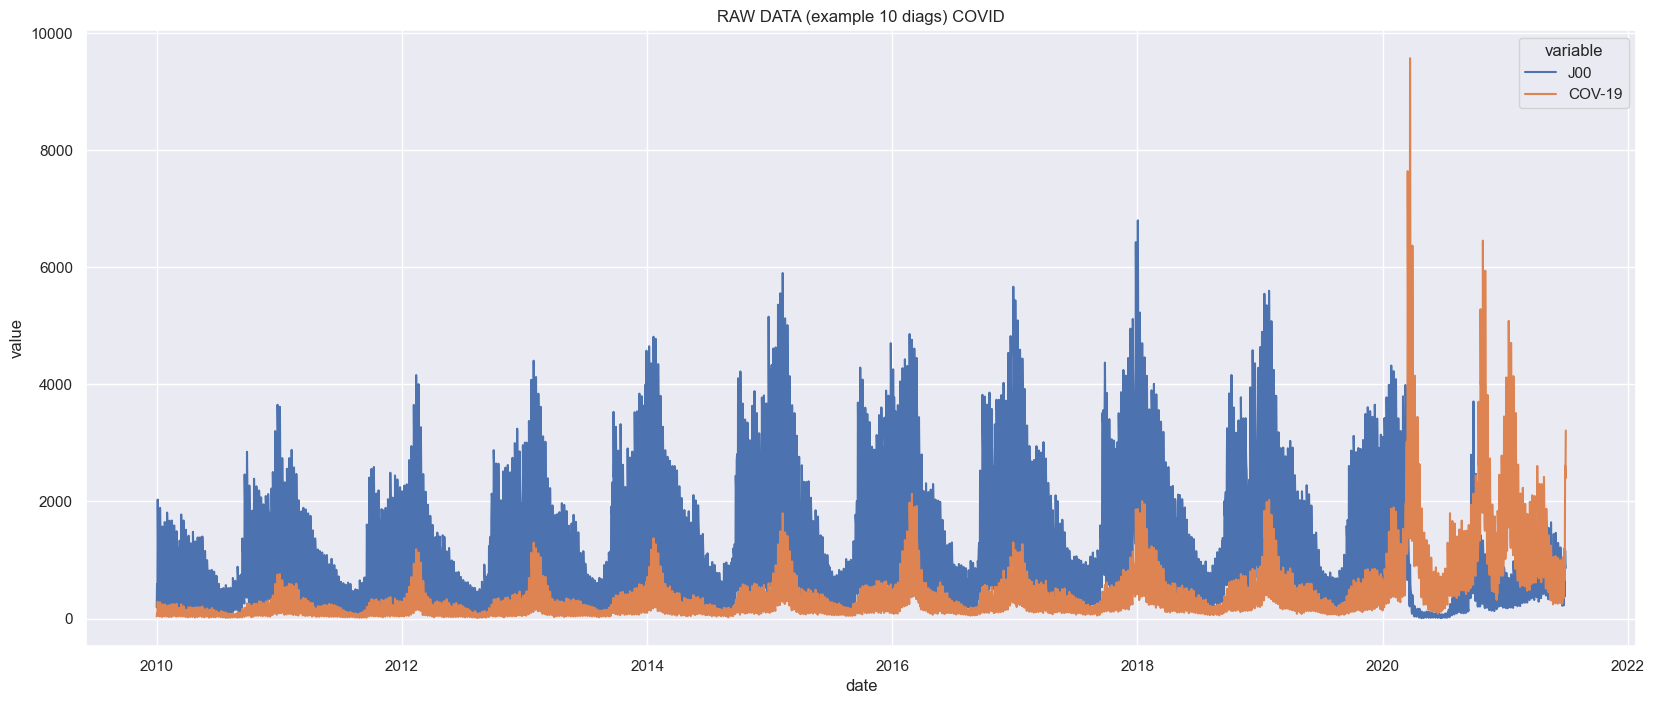

In [14]:
# RAW DATA --------------------------------------------------------------
df = pd.read_csv('C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/input data/longitudinalitat_DIAGNOSTICS_GROUPED.csv', index_col=0)
df['COV-19'] = df["B34"]+df["U07"]   # join cov19 codes
df = df.drop(['B34', 'U07'], axis=1)

df.index = pd.to_datetime(df.index)
d = pd.to_datetime('2000-01-01')
mask = df.index < d
df = df.loc[~mask]

d = pd.to_datetime('2010-01-01')
mask = df.index < d
df = df.loc[~mask]

df["Overall"] = df.iloc[:, 1:].sum(axis=1)
display(df)

# plot example 10 diags -------------------------
def plot_example(df,title):
    # PLOT RAW DATA (example 10 diags)
    dff = df
    dff["date"] = dff.index
    dff = dff[['J00','COV-19','date']]
    sns.set(rc={'figure.figsize':(20,8)})
    sns.lineplot(data=dff.replace('nan', float('nan')).melt(id_vars=['date']),x='date', y='value', hue='variable').set(title=title)
    
plot_example(df,"RAW DATA (example 10 diags) COVID")

In [15]:
# Define function for train-test split
def split_train_test(df, split_ratio=0.8):
    """
    Splits a dataframe into train and test sets using the given split ratio.

    Parameters:
    df (pd.DataFrame): The input dataframe to split.
    split_ratio (float): The fraction of data to be used for training (default is 0.8).

    Returns:
    train_df (pd.DataFrame): Training dataset.
    test_df (pd.DataFrame): Testing dataset.
    """
    split_idx = int(len(df) * split_ratio)  # Compute split index
    train_df = df.iloc[:split_idx].reset_index(drop=True)
    test_df = df.iloc[split_idx:].reset_index(drop=True)
    
    return train_df, test_df


def evaluate_model(model, X_test, Y_test, sliding_window=10):
    """
    Evaluate the model using a sliding window approach.

    Args:
        model: Trained Keras model.
        X_test: Test input data (shape: (samples, lookback, 1)).
        Y_test: True future values (shape: (samples, n_pred)).
        sliding_window: Number of test samples to slide over.
    
    Returns:
        Plots the MSE, MAE, and Loss over time.
    """

    mse_list = []
    mae_list = []
    loss_list = []

    num_samples = len(X_test) - sliding_window + 1  # Number of sliding steps

    for i in range(num_samples):
        X_window = X_test[i : i + sliding_window]  # Get sliding window input
        Y_window_true = Y_test[i : i + sliding_window]  # True values

        # Predict using the model
        Y_window_pred = model.predict(X_window, verbose=0)

        # Compute metrics
        mse = mean_squared_error(Y_window_true, Y_window_pred)
        mae = mean_absolute_error(Y_window_true, Y_window_pred)
        loss = np.mean(np.abs(Y_window_true - Y_window_pred))  # Approximate loss (MAE)

        # Store metrics
        mse_list.append(mse)
        mae_list.append(mae)
        loss_list.append(loss)

    # Plot results
    plt.figure(figsize=(15, 5))

    # Plot MSE
    plt.subplot(3, 1, 1)
    plt.plot(mse_list, label="MSE")
    plt.xlabel("Sliding Window Step")
    plt.ylabel("MSE")
    plt.title("Mean Squared Error (MSE)")
    plt.legend()

    # Plot MAE
    plt.subplot(3, 1, 2)
    plt.plot(mae_list, label="MAE", color="orange")
    plt.xlabel("Sliding Window Step")
    plt.ylabel("MAE")
    plt.title("Mean Absolute Error (MAE)")
    plt.legend()

    # Plot Loss
    plt.subplot(3, 1, 3)
    plt.plot(loss_list, label="Loss", color="red")
    plt.xlabel("Sliding Window Step")
    plt.ylabel("Loss")
    plt.title("Loss Over Sliding Window")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [16]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)                  # to imputs to stabilize training
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)   # self attention to normalized input 
    x = layers.Dropout(dropout)(x) # (dropout to reduce overfitting)
    res = x + inputs               # attention output added to original inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)                       # again after resid connection
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="tanh")(x) # point-wise convol.: Expands feature dim to ff_dim using tanh activ
    x = layers.Dropout(dropout)(x)                                         # dropout again
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)          # reduces feature dim back to match input size
    return x + res


def build_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0, n_pred=1):
    inputs = keras.Input(shape=input_shape) #defines input tensor
    x = inputs 
    for _ in range(num_transformer_blocks): #apply num_transformer_blocks transformer encoder layers seq.
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout) #uses previous defined trans_encoder layer

    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x) # reduces seq dimension (timesteps) averaging for each fature channel
    for dim in mlp_units:                                              # multi layer perceptron (dropout to avoid overfitting)
        x = layers.Dense(dim, activation="tanh")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(n_pred)(x)
    return keras.Model(inputs, outputs)


# defaults to 50 epochs total and 20 warmup steps
class CustomCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-4, max_lr=1e-3, min_lr=1e-5, warmup_steps=20, total_steps=50):
        self.initial_lr = initial_lr  # Starting learning rate (0.01)
        self.max_lr = max_lr          # Maximum learning rate (0.1)
        self.min_lr = min_lr          # Final learning rate (0.0001)
        self.warmup_steps = warmup_steps  # Number of warmup steps to reach max_lr
        self.total_steps = total_steps    # Total number of steps (decay after warmup)

    def __call__(self, step):
        # Warm-up phase: linearly increase to max_lr
        if step < self.warmup_steps:
            return self.initial_lr + (self.max_lr - self.initial_lr) * (step / self.warmup_steps)

        # Cosine decay phase after warmup
        decay_steps = self.total_steps - self.warmup_steps
        step_after_warmup = step - self.warmup_steps
        cosine_decay = 0.5 * (1 + math.cos(math.pi * step_after_warmup / decay_steps))
        decayed = (self.max_lr - self.min_lr) * cosine_decay + self.min_lr
        return decayed
    
def train_given_model_and_data(model, X, Y, batch_size=1024, model_name=None, epochs=100, save_history=False, save_model=True, save_memory=True, shuffle=False, callbacks=None):
    if save_memory: #configure GPU memory growth
        # prepare for measuring memory
        gpus = tf.config.experimental.list_physical_devices('GPU')
        if gpus:
            try:
                for gpu in gpus:
                    tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as e:
                print(e)
    if callbacks is None: # define callbacks (If no callbacks are provided, it automatically enables Early Stopping)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)
        callbacks = [early_stop]

    if not os.path.exists(f'{model_name}'): #check if model exist and run if not
        history = model.fit(x=X, 
                            y=Y, 
                            batch_size=batch_size,  # batch gradient descent (batch size 1024)
                            epochs=epochs, 
                            shuffle=shuffle,        # Allows shuffling
                            validation_split=0.3,   # 30% data for validation
                            callbacks=callbacks)
    else:
        print(f"model {model_name} already exists")
        return

    if model_name is None:
        model_name = "testing"

    if save_history: # save training history
        with open(f'{model_name}_history.pkl', 'wb') as file_pi:
            pickle.dump(history.history, file_pi)
    
    if save_model and epochs > 1: # save model
        model.save(model_name)
        
    if save_memory: # log memory usage (optional)
        # save memory usave
        # Get memory information
        memory_info = tf.config.experimental.get_memory_info('GPU:0')
        with open('memory.csv', 'a') as resultcsv:
            resultcsv.write(f"{model_name},{memory_info['peak']},train\n")
        print(f"Current memory usage: {memory_info['current'] / (1024**2)} MB")
        print(f"Peak memory usage: {memory_info['peak'] / (1024**2)} MB")

In [17]:
# Code defincition (assuming train and test already computed)
code = 'J00_NOPAND'

# Set default values
forecast= [1,7,14,30,60,182,365]      
lookback= [1,7,14,30,60,182,365]

#Transformer model
head_size=2              # dimensions of each attention head(If you have num_heads=2, attention 2 * head_size = 4 dimensions.)
num_heads=2              # number attention head (More headsimprove ability to focus on different aspects but increase computational cost.)
num_transformer_blocks=2 # n transformer layers (More blocks can improve the model's capacity but may lead to overfitting.)
ff_dim=8                 # dimensionality feed-forward layer  (more increases capacity but adds cost)

# Multi-Layer Perceptron (MLP) Parameters
mlp_units=32     # n neurons fully connected feed forward network (MLP)
mlp_dropout=0.25 # dropout rate MLP layers to prevent overfitting (% neurons randomly dropper durinhg training)

# General Regularization Parameters
dropout=0.5

# Optimization and Training Parameters
learning_rate = 0.001  # step size for gradient updates during training.( more speeds up but cause instabiliy)
epochs=100             # max number of times to train
early_stop_patience=15 # if not improvement

input_directory = f'C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/diagnostic_data' # define data dir
batchSize=16               # how many samples processing in parallel during training
shuffle=False              # randomize order of training data??

LR_init=learning_rate
LR_min=LR_init*10
LR_max=LR_init*10*10

# prior to start (the model search if the model is already computed on the same folder it is present. If you have
# models already computed move them to the scripts folder.)

In [21]:
# Define parameter grid
param_grid = {
    'lookback': [14],
    'forecast': [30],
    'head_size': [2,8,16,32],
    'num_heads': [2,4,8],
    'num_transformer_blocks': [1,2,4],
    'ff_dim': [16,32,64],
    'mlp_units': [16,32,64],
    'dropout': [0.1,0.25,0.5],
    'mlp_dropout': [0.1,0.25,0.5],
    'batch_size': [32],
    'learning_rate': [0.001]
}

# Create list of parameter combinations (Cartesian product)
param_combinations = list(product(*param_grid.values()))

# Optionally: convert to list of dictionaries for easier iteration
param_dicts = [dict(zip(param_grid.keys(), values)) for values in param_combinations]

print(f"Total combinations: {len(param_combinations)}")

random.seed(42)
sampled_dicts = random.sample(param_dicts, 500)

Total combinations: 2916


In [ ]:
for params in sampled_dicts:
    lb = params['lookback']
    fh = params['forecast']
    head_size = params['head_size']
    num_heads = params['num_heads']
    num_transformer_blocks = params['num_transformer_blocks']
    ff_dim = params['ff_dim']
    mlp_units = params['mlp_units']
    dropout = params['dropout']
    mlp_dropout = params['mlp_dropout']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']

    csvFile = f'{input_directory}/{code}_train_example.csv'

    # Prepare data
    X, Y = data_preparation.prepare_data(csvFile, lb, fh, debug=True, univariate=True)

    start_time = time.perf_counter()

    model = build_model(
        input_shape=(lb, 1),
        head_size=head_size,
        num_heads=num_heads,
        ff_dim=ff_dim,
        num_transformer_blocks=num_transformer_blocks,
        mlp_units=[mlp_units],
        mlp_dropout=mlp_dropout,
        dropout=dropout,
        n_pred=fh
    )

    # Learning rate scheduler
    scheduler = CustomCosineDecay(
        initial_lr=learning_rate,
        max_lr=learning_rate * 10,
        min_lr=learning_rate / 10,
        warmup_steps=epochs // 5,
        total_steps=epochs
    )

    # Callbacks
    callbacks = [
        tf.keras.callbacks.LearningRateScheduler(scheduler),
        tf.keras.callbacks.EarlyStopping(
            patience=early_stop_patience,
            monitor='val_loss',
            mode='min',
            restore_best_weights=True
        )
    ]

    model.compile(
        loss='MSE',
        metrics=['mae', 'mse'],
        optimizer=Adam()
    )

    # Build unique model name
    model_name = f"{code}_transf_lb{lb}_fh{fh}_hs{head_size}_nh{num_heads}_blk{num_transformer_blocks}_ff{ff_dim}_mlp{mlp_units}_dr{dropout}_mdr{mlp_dropout}_bs{batch_size}_lr{learning_rate}"

    # Train the model
    train_given_model_and_data(
        model, X, Y,
        batch_size=batch_size,
        model_name=model_name,
        epochs=epochs,
        save_model=True,
        save_memory=False,
        callbacks=callbacks
    )

    finish_time = time.perf_counter()
    print(f"✅ Finished model: {model_name}")
    print(f"⏱️ Time taken: {finish_time - start_time:.2f} seconds\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2879, 14, 1), Y=(2879, 30)
Epoch 1/100
63/63 [==============================] - 4s 18ms/step - loss: 0.0466 - mae: 0.1585 - mse: 0.0466 - val_loss: 0.0486 - val_mae: 0.1594 - val_mse: 0.0486 - lr: 0.0010
Epoch 2/100
63/63 [==============================] - 1s 14ms/step - loss: 0.0234 - mae: 0.1138 - mse: 0.0234 - val_loss: 0.0268 - val_mae: 0.1252 - val_mse: 0.0268 - lr: 0.0014
Epoch 3/100
63/63 [==============================] - 1s 13ms/step - loss: 0.0194 - mae: 0.1063 - mse: 0.0194 - val_loss: 0.0220 - val_mae: 0.1158 - val_mse: 0.0220 - lr: 0.0019
Epoch 4/100
63/63 [==============================] - 1s 15ms/step - loss: 0.0160 - mae: 0.0953 - 

INFO:tensorflow:Assets written to: J00_NOPAND_transf_lb14_fh30_hs32_nh4_blk4_ff32_mlp16_dr0.1_mdr0.1_bs32_lr0.001\assets


INFO:tensorflow:Assets written to: J00_NOPAND_transf_lb14_fh30_hs32_nh4_blk4_ff32_mlp16_dr0.1_mdr0.1_bs32_lr0.001\assets


✅ Finished model: J00_NOPAND_transf_lb14_fh30_hs32_nh4_blk4_ff32_mlp16_dr0.1_mdr0.1_bs32_lr0.001
⏱️ Time taken: 29.92 seconds

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2879, 14, 1), Y=(2879, 30)
Epoch 1/100
63/63 [==============================] - 4s 15ms/step - loss: 0.0277 - mae: 0.1245 - mse: 0.0277 - val_loss: 0.0203 - val_mae: 0.1043 - val_mse: 0.0203 - lr: 0.0010
Epoch 2/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0137 - mae: 0.0863 - mse: 0.0137 - val_loss: 0.0147 - val_mae: 0.0826 - val_mse: 0.0147 - lr: 0.0014
Epoch 3/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0121 - mae: 0.0816 - mse: 0.0121 - val_loss: 0.0131 - val_mae: 0.0775 -

INFO:tensorflow:Assets written to: J00_NOPAND_transf_lb14_fh30_hs2_nh4_blk4_ff32_mlp64_dr0.5_mdr0.1_bs32_lr0.001\assets


...

✅ Finished model: J00_NOPAND_transf_lb14_fh30_hs2_nh2_blk1_ff32_mlp32_dr0.1_mdr0.5_bs32_lr0.001
⏱️ Time taken: 9.78 seconds

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2879, 14, 1), Y=(2879, 30)
Epoch 1/100
63/63 [==============================] - 4s 20ms/step - loss: 0.0580 - mae: 0.1792 - mse: 0.0580 - val_loss: 0.0499 - val_mae: 0.1647 - val_mse: 0.0499 - lr: 0.0010
Epoch 2/100
63/63 [==============================] - 1s 15ms/step - loss: 0.0282 - mae: 0.1218 - mse: 0.0282 - val_loss: 0.0262 - val_mae: 0.1184 - val_mse: 0.0262 - lr: 0.0014
Epoch 3/100
63/63 [==============================] - 1s 15ms/step - loss: 0.0207 - mae: 0.1058 - mse: 0.0207 - val_loss: 0.0201 - val_mae: 0.1046 - v

INFO:tensorflow:Assets written to: J00_NOPAND_transf_lb14_fh30_hs16_nh4_blk4_ff16_mlp32_dr0.25_mdr0.5_bs32_lr0.001\assets


INFO:tensorflow:Assets written to: J00_NOPAND_transf_lb14_fh30_hs16_nh4_blk4_ff16_mlp32_dr0.25_mdr0.5_bs32_lr0.001\assets


✅ Finished model: J00_NOPAND_transf_lb14_fh30_hs16_nh4_blk4_ff16_mlp32_dr0.25_mdr0.5_bs32_lr0.001
⏱️ Time taken: 43.32 seconds

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2879, 14, 1), Y=(2879, 30)
Epoch 1/100
63/63 [==============================] - 3s 19ms/step - loss: 0.0422 - mae: 0.1507 - mse: 0.0422 - val_loss: 0.0404 - val_mae: 0.1476 - val_mse: 0.0404 - lr: 0.0010
Epoch 2/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0210 - mae: 0.1076 - mse: 0.0210 - val_loss: 0.0228 - val_mae: 0.1158 - val_mse: 0.0228 - lr: 0.0014
Epoch 3/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0163 - mae: 0.0944 - mse: 0.0163 - val_loss: 0.0180 - val_mae: 0.1000 

63/63 [==============================] - 1s 10ms/step - loss: 0.0096 - mae: 0.0716 - mse: 0.0096 - val_loss: 0.0119 - val_mae: 0.0701 - val_mse: 0.0119 - lr: 0.0081
Epoch 45/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0093 - mae: 0.0698 - mse: 0.0093 - val_loss: 0.0118 - val_mae: 0.0702 - val_mse: 0.0118 - lr: 0.0080
Epoch 46/100
63/63 [==============================] - 1s 11ms/step - loss: 0.0091 - mae: 0.0682 - mse: 0.0091 - val_loss: 0.0118 - val_mae: 0.0706 - val_mse: 0.0118 - lr: 0.0078
Epoch 47/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0091 - mae: 0.0688 - mse: 0.0091 - val_loss: 0.0119 - val_mae: 0.0705 - val_mse: 0.0119 - lr: 0.0076
Epoch 48/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0091 - mae: 0.0678 - mse: 0.0091 - val_loss: 0.0117 - val_mae: 0.0699 - val_mse: 0.0117 - lr: 0.0075
Epoch 49/100
 1/63 [..............................] - ETA: 0s - loss: 0.0014 - mae: 0.0308 - mse: 0.0014

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optional: Define SMAPE function
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    smape_val = np.mean(np.where(denominator == 0, 0, diff / denominator)) * 100
    return smape_val

# Store evaluation results
results = []

# === Loop for testing ===
for params in sampled_dicts:
    # Unpack parameters
    lb = params['lookback']
    fh = params['forecast']
    head_size = params['head_size']
    num_heads = params['num_heads']
    num_transformer_blocks = params['num_transformer_blocks']
    ff_dim = params['ff_dim']
    mlp_units = params['mlp_units']
    dropout = params['dropout']
    mlp_dropout = params['mlp_dropout']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']

    model_name = f"{code}_transf_lb{lb}_fh{fh}_hs{head_size}_nh{num_heads}_blk{num_transformer_blocks}_ff{ff_dim}_mlp{mlp_units}_dr{dropout}_mdr{mlp_dropout}_bs{batch_size}_lr{learning_rate}"

    # Load model
    if not os.path.exists(model_name):
        print(f"Skipping {model_name} (model not found)")
        continue
    model = tf.keras.models.load_model(model_name, compile=False)

    # Load test data
    test_csv = f'{input_directory}/{code}_test_example.csv'
    X_test, Y_test = data_preparation.prepare_data(test_csv, lb, fh, debug=True, univariate=True)

    # Make predictions
    Y_pred = model.predict(X_test)

    # Compute metrics
    mae = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    smape_val = smape(Y_test, Y_pred)

    results.append({
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "smape": smape_val
    })

    # Optional: plot first few predictions
    plt.figure(figsize=(10, 4))
    plt.plot(Y_test[:fh], label="Actual", marker='o')
    plt.plot(Y_pred[:fh], label="Predicted", marker='x')
    plt.title(f"{model_name} — Forecast vs Actual")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("smape")  # or any other metric
import ace_tools as tools; tools.display_dataframe_to_user(name="Model Evaluation Results", dataframe=results_df)